# US Equity Portfolio - Monte Carlo Simulation

## Notebook Overview

This notebook evaluates simulated one-year portfolio outcomes using the project's historical
mean-return and volatility parameters, and examines the resulting downside risk (Value at Risk
and Conditional Value at Risk).

**This is scenario analysis, not a forecast.** Daily portfolio returns are simulated as
independent draws from a normal distribution parameterized by the historical sample mean and
standard deviation of the portfolio's own daily returns. The results describe a distribution of
hypothetical outcomes consistent with those historical statistics under that assumption - they
are not a prediction of what the portfolio will actually do.

All calculations reuse the project's approved `src.simulation` functions; this notebook does not
recreate any Monte Carlo, VaR, or CVaR formula independently.

## Imports and Configuration

Only the packages needed for this notebook are imported below. `MONTE_CARLO_SIMULATIONS`,
`MONTE_CARLO_DAYS`, `RANDOM_SEED`, and `PORTFOLIO_WEIGHTS` come directly from `config.py`, and
all simulation logic comes from the approved `src.simulation` module. `src.visualizations` is
intentionally not imported, since it forces the non-interactive `Agg` backend and always writes
chart files to disk - unnecessary here.

The cell below locates the project root by walking upward from the current working directory
until it finds `config.py`, and adds it to `sys.path`, so the notebook works whether Jupyter's
working directory is the repository root or the `notebooks/` folder itself.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Locate the project root (the directory containing config.py) by walking upward."""
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "config.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root (config.py not found).")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\andhr\Downloads\us-equity-portfolio-analytics\us-equity-portfolio-analytics


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import Markdown, display

from config import MONTE_CARLO_DAYS, MONTE_CARLO_SIMULATIONS, PORTFOLIO_WEIGHTS, RANDOM_SEED
from src import data_loader, metrics, simulation

sns.set_theme(style="whitegrid")
%matplotlib inline

## Load Cached Data

Prices are loaded using the approved `load_price_data()` function, and daily returns are
calculated using the approved `calculate_daily_returns()` function. Neither downloads any data;
both read and process the already-validated cache.

In [3]:
prices = data_loader.load_price_data()
returns = metrics.calculate_daily_returns(prices)

print(f"Return observations: {len(returns)} trading days "
      f"({returns.index.min().date()} to {returns.index.max().date()})")

Return observations: 1253 trading days (2021-09-14 to 2026-09-10)


## Historical Portfolio Parameters

The approved `estimate_portfolio_parameters()` function computes the weighted portfolio's
historical daily mean return and daily volatility (both un-annualized). These two numbers are
the only inputs the simulation below draws from history - everything else is randomness.

In [4]:
portfolio_parameters = simulation.estimate_portfolio_parameters(returns, PORTFOLIO_WEIGHTS)

print(f"Mean daily portfolio return: {portfolio_parameters['Mean Daily Return']:.4%}")
print(f"Daily portfolio volatility:  {portfolio_parameters['Daily Volatility']:.4%}")

Mean daily portfolio return: 0.1344%
Daily portfolio volatility:  1.4735%


## Run Monte Carlo Simulation

The approved `run_monte_carlo_simulation()` function runs the full simulation end to end
(simulating return paths, compounding wealth, and computing terminal returns, summary
statistics, downside probabilities, VaR, and CVaR) using the project's configured simulation
count, horizon, and random seed, so the results are reproducible.

In [5]:
simulation_result = simulation.run_monte_carlo_simulation(
    returns,
    simulations=MONTE_CARLO_SIMULATIONS,
    days=MONTE_CARLO_DAYS,
    seed=RANDOM_SEED,
    weights=PORTFOLIO_WEIGHTS,
)

print(f"Ran {MONTE_CARLO_SIMULATIONS:,} simulations over a {MONTE_CARLO_DAYS}-day horizon "
      f"(seed={RANDOM_SEED}).")

Ran 10,000 simulations over a 252-day horizon (seed=42).


## Simulation Summary

Combines the approved `create_simulation_summary()` output with the VaR and CVaR already
computed by `run_monte_carlo_simulation()` into one table. Return and probability figures are
shown as percentages; terminal wealth figures are shown as a multiple of the initial investment
(1.00x = breakeven).

In [6]:
summary = simulation_result["summary"]

summary_display = {}
for key, value in summary.items():
    if "Wealth" in key:
        summary_display[key] = f"{value:.3f}x"
    elif key == "Probability of Loss":
        summary_display[key] = f"{value:.1%}"
    else:
        summary_display[key] = f"{value:.2%}"
summary_display["95% VaR"] = f"{simulation_result['var']:.2%}"
summary_display["95% CVaR"] = f"{simulation_result['cvar']:.2%}"

pd.Series(summary_display, name="Value").to_frame()

,Value
Mean Terminal Return,40.60%
Median Terminal Return,36.66%
5th Percentile Return,-7.24%
95th Percentile Return,100.86%
Probability of Loss,9.1%
Expected Terminal Wealth,1.406x
5th Percentile Wealth,0.928x
95th Percentile Wealth,2.009x
95% VaR,7.24%
95% CVaR,15.62%


## Monte Carlo Wealth Paths

A readable sample of individual simulated wealth paths (at most 50, drawn with the same
`RANDOM_SEED` for reproducibility), overlaid with the median, 5th-percentile, and 95th-percentile
paths across all simulations - not just the sampled subset.

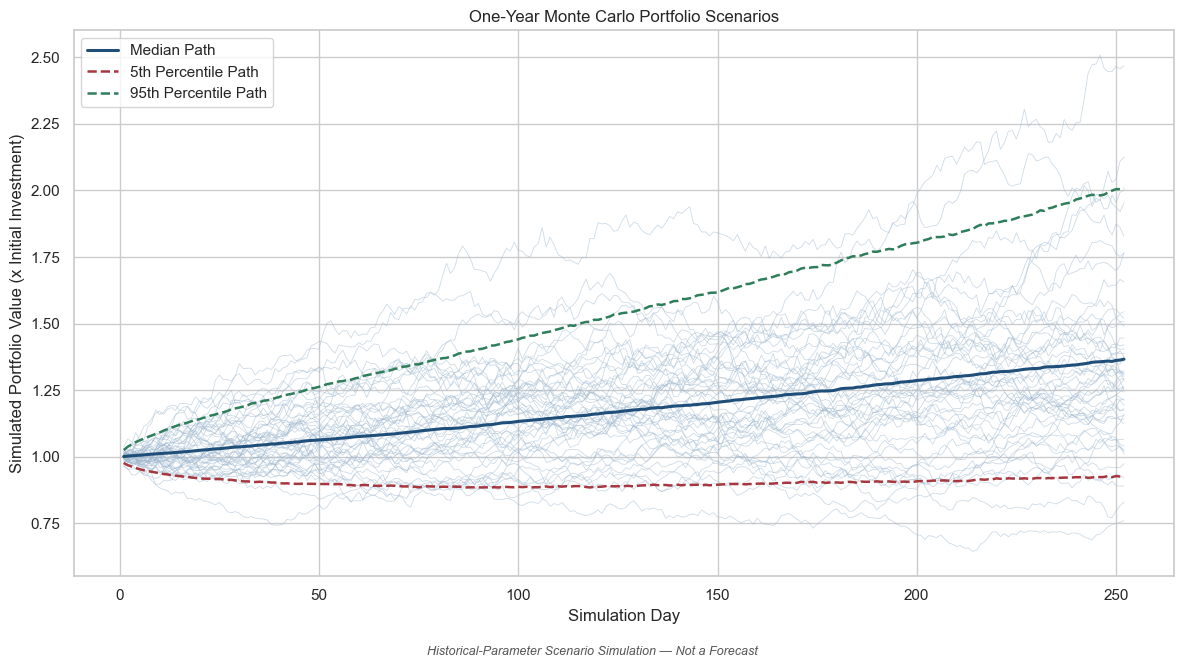

Displaying 50 of 10,000 simulated paths, plus the median, 5th percentile, and 95th percentile paths computed across all simulations.


In [7]:
wealth_paths = simulation_result["wealth_paths"]
n_simulations = wealth_paths.shape[1]
sample_size = min(50, n_simulations)

rng = np.random.default_rng(RANDOM_SEED)
sample_columns = rng.choice(wealth_paths.columns, size=sample_size, replace=False)

median_path = wealth_paths.median(axis=1)
p05_path = wealth_paths.quantile(0.05, axis=1)
p95_path = wealth_paths.quantile(0.95, axis=1)

fig, ax = plt.subplots(figsize=(12, 6.5))
for column in sample_columns:
    ax.plot(wealth_paths.index, wealth_paths[column], color="#9fb8cf", linewidth=0.6, alpha=0.5, zorder=1)

ax.plot(median_path.index, median_path, color="#1f4e79", linewidth=2.2, label="Median Path", zorder=3)
ax.plot(p05_path.index, p05_path, color="#a6373f", linewidth=1.8, linestyle="--", label="5th Percentile Path", zorder=3)
ax.plot(p95_path.index, p95_path, color="#2e7d5b", linewidth=1.8, linestyle="--", label="95th Percentile Path", zorder=3)

ax.set_title("One-Year Monte Carlo Portfolio Scenarios")
ax.set_xlabel("Simulation Day")
ax.set_ylabel("Simulated Portfolio Value (x Initial Investment)")
ax.legend(loc="best")
fig.text(
    0.5, -0.02,
    "Historical-Parameter Scenario Simulation \u2014 Not a Forecast",
    ha="center", fontsize=9, style="italic", color="#555555",
)
fig.tight_layout()
plt.show()

print(f"Displaying {sample_size} of {n_simulations:,} simulated paths, plus the median, "
      "5th percentile, and 95th percentile paths computed across all simulations.")

## Terminal Return Distribution

The distribution of simulated one-year terminal returns across all simulations, with the
median, the 5th percentile / 95% VaR threshold, and the CVaR level marked.

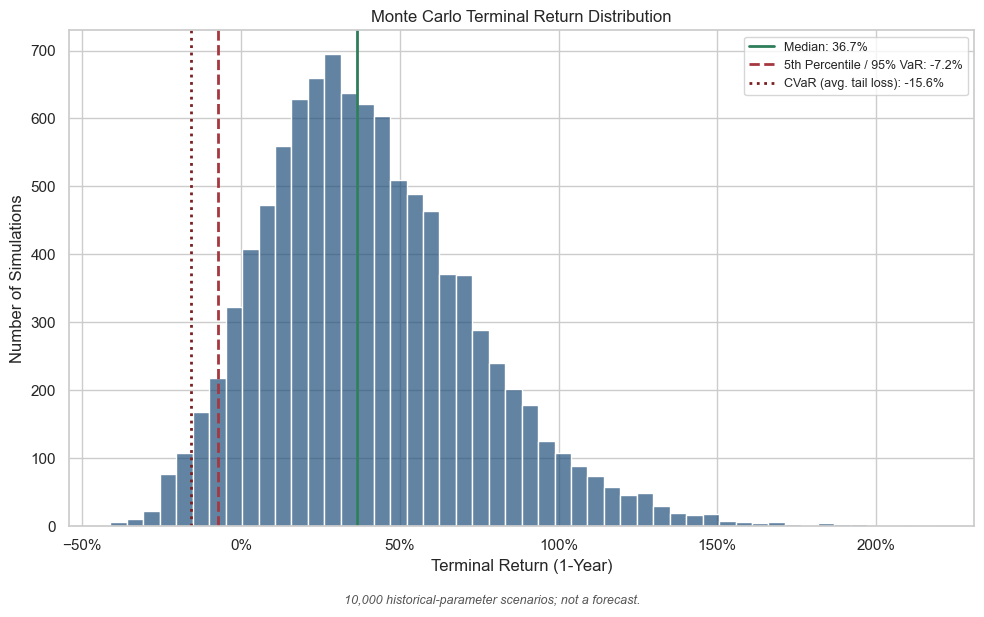

In [8]:
terminal_returns = simulation_result["terminal_returns"]
median_return = terminal_returns.median()
var_threshold_return = terminal_returns.quantile(0.05)
var_value = simulation_result["var"]
cvar_value = simulation_result["cvar"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(terminal_returns, bins=50, color="#1f4e79", alpha=0.7, ax=ax)

ax.axvline(median_return, color="#2e7d5b", linewidth=2, label=f"Median: {median_return:.1%}")
ax.axvline(
    var_threshold_return, color="#a6373f", linewidth=2, linestyle="--",
    label=f"5th Percentile / 95% VaR: {var_threshold_return:.1%}",
)
if cvar_value > 0:
    ax.axvline(-cvar_value, color="#7a2020", linewidth=2, linestyle=":", label=f"CVaR (avg. tail loss): -{cvar_value:.1%}")

ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_title("Monte Carlo Terminal Return Distribution")
ax.set_xlabel("Terminal Return (1-Year)")
ax.set_ylabel("Number of Simulations")
ax.legend(loc="best", fontsize=9)
fig.text(
    0.5, -0.02,
    f"{len(terminal_returns):,} historical-parameter scenarios; not a forecast.",
    ha="center", fontsize=9, style="italic", color="#555555",
)
fig.tight_layout()
plt.show()

## Downside Risk

`calculate_downside_probabilities()` reports how often the simulated scenarios fell below the
starting value and several loss thresholds. These are frequencies observed across the simulated
scenarios, not a forecast probability that the portfolio will lose money.

In [9]:
downside = simulation_result["downside_probabilities"]

downside.map(lambda v: f"{v:.1%}").to_frame(name="Share of Simulated Scenarios")

,Share of Simulated Scenarios
Probability of Loss,9.1%
Probability Return < -10%,3.9%
Probability Return < -20%,1.2%
Probability Return < -30%,0.2%


In [10]:
loss_share = downside["Probability of Loss"]
minus10_share = downside["Probability Return < -10%"]
minus20_share = downside["Probability Return < -20%"]
minus30_share = downside["Probability Return < -30%"]

downside_text = (
    f"Of the {MONTE_CARLO_SIMULATIONS:,} simulated one-year scenarios, **{loss_share:.1%}** ended "
    "below the starting portfolio value. **" + f"{minus10_share:.1%}" + "** of scenarios ended more "
    "than 10% below the starting value, **" + f"{minus20_share:.1%}" + "** more than 20% below, and "
    "**" + f"{minus30_share:.1%}" + "** more than 30% below. These figures describe the frequency of "
    "outcomes within the simulated scenario set under the model's assumptions - they are not a "
    "probability forecast of what will actually happen to the portfolio."
)

display(Markdown(downside_text))

Of the 10,000 simulated one-year scenarios, **9.1%** ended below the starting portfolio value. **3.9%** of scenarios ended more than 10% below the starting value, **1.2%** more than 20% below, and **0.2%** more than 30% below. These figures describe the frequency of outcomes within the simulated scenario set under the model's assumptions - they are not a probability forecast of what will actually happen to the portfolio.

## VaR and CVaR Interpretation

Both figures use the project's positive-loss convention: a larger positive number means a larger
loss. They are computed directly by `src.simulation.calculate_var()` and `calculate_cvar()`; this
notebook does not recompute them.

- **Value at Risk (95% VaR)**: the threshold loss at the 95% confidence level. 5% of simulated
  scenarios lost more than this amount; the other 95% lost less (or gained). A 95% VaR of 7% means
  the worst 5% of simulated outcomes lost more than 7%.
- **Conditional Value at Risk (95% CVaR)**, also called Expected Shortfall: the *average* loss
  among only that worst 5% of scenarios - i.e. the average outcome conditional on already being in
  the tail beyond the VaR threshold. CVaR is always at least as large as VaR, since it averages
  over the more extreme outcomes within that tail.

## Key Findings

The summary below is generated programmatically from the simulation result computed above, so it
remains valid if the underlying cached dataset, seed, or simulation parameters change.

In [11]:
median_terminal_return = summary["Median Terminal Return"]
p05_terminal_return = summary["5th Percentile Return"]

findings = (
    f"- The median simulated one-year terminal return was **{median_terminal_return:.1%}**, while "
    f"the 5th percentile simulated outcome was **{p05_terminal_return:.1%}**.\n"
    f"- **{loss_share:.1%}** of the {MONTE_CARLO_SIMULATIONS:,} simulated scenarios ended below the "
    "starting portfolio value.\n"
    f"- The 95% Value at Risk (VaR) was **{var_value:.1%}**, and the 95% Conditional VaR (CVaR) - the "
    f"average loss among the worst 5% of scenarios - was **{cvar_value:.1%}**.\n"
    "- These results are specific to the current cached dataset, the configured random seed, and the "
    "model's normal-distribution assumption. They describe a simulated scenario distribution, not a "
    "forecast or a guarantee of future portfolio behavior."
)

display(Markdown(findings))

- The median simulated one-year terminal return was **36.7%**, while the 5th percentile simulated outcome was **-7.2%**.
- **9.1%** of the 10,000 simulated scenarios ended below the starting portfolio value.
- The 95% Value at Risk (VaR) was **7.2%**, and the 95% Conditional VaR (CVaR) - the average loss among the worst 5% of scenarios - was **15.6%**.
- These results are specific to the current cached dataset, the configured random seed, and the model's normal-distribution assumption. They describe a simulated scenario distribution, not a forecast or a guarantee of future portfolio behavior.

## Model Limitations

- **Historical parameters may not persist**: the simulation is parameterized entirely by this
  portfolio's historical daily mean return and volatility, which can change materially going
  forward.
- **Normal-return assumption**: daily returns are simulated as independent draws from a normal
  distribution, which is a simplification of how real asset returns actually behave.
- **Fat tails are not explicitly modeled**: real markets exhibit more frequent extreme moves than
  a normal distribution predicts, so this simulation likely under-represents severe scenarios.
- **Regime changes and structural breaks are not modeled**: the simulation assumes the historical
  mean/volatility regime continues unchanged; it cannot anticipate shifts such as a change in
  monetary policy, a market crisis, or a change in the underlying businesses.
- **Parameter-estimation uncertainty**: the historical mean and volatility are themselves
  estimates from a finite sample and carry their own uncertainty, which this simulation does not
  incorporate.
- **This is not a forecast**: the simulation describes a distribution of hypothetical outcomes
  consistent with historical statistics under stated assumptions - it does not predict what this
  portfolio will actually do over the next year.